In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.signals import add_random_signal, add_momentum_signal, add_reversal_signal
from src.portfolio import make_long_short_weights
from src.backtest import run_backtest, compute_turnover, apply_transaction_costs
from src.metrics import summarize_returns

In [2]:
panel = pd.read_csv(PROJECT_ROOT / "data/processed/price_panel.csv")
panel["date"] = pd.to_datetime(panel["date"])

panel.head()

,date,ticker,close,ret_1d,fwd_ret_1d,fwd_ret_5d,vol_20d,vol_20d_ann
0,2020-01-02,AAPL,72.333870,NaN,-0.009722,0.030897,NaN,NaN
1,2020-01-03,AAPL,71.630638,-0.009722,0.007968,0.043371,NaN,NaN
2,2020-01-06,AAPL,72.201416,0.007968,-0.004703,0.057238,NaN,NaN
3,2020-01-07,AAPL,71.861839,-0.004703,0.016086,0.047890,NaN,NaN
4,2020-01-08,AAPL,73.017838,0.016086,0.021241,0.026881,NaN,NaN


In [3]:
df = add_random_signal(panel, seed=42)
df = add_momentum_signal(df, lookback=5)
df = add_reversal_signal(df, lookback=5)

df[["date", "ticker", "signal_random", "signal_mom_5d", "signal_rev_5d"]].head(10)

,date,ticker,signal_random,signal_mom_5d,signal_rev_5d
0,2020-01-02,AAPL,0.304717,NaN,NaN
1,2020-01-03,AAPL,-1.039984,NaN,NaN
2,2020-01-06,AAPL,0.750451,NaN,NaN
3,2020-01-07,AAPL,0.940565,NaN,NaN
4,2020-01-08,AAPL,-1.951035,NaN,NaN
5,2020-01-09,AAPL,-1.302180,0.030897,-0.030897
6,2020-01-10,AAPL,0.127840,0.043371,-0.043371
7,2020-01-13,AAPL,-0.316243,0.057238,-0.057238
8,2020-01-14,AAPL,-0.016801,0.047890,-0.047890
9,2020-01-15,AAPL,-0.853044,0.026881,-0.026881


In [4]:
weights_random = make_long_short_weights(
    signal_df=df,
    signal_col="signal_random",
    top_k=5,
    bottom_k=5,
    gross_exposure=1.0
)

returns_random = run_backtest(
    weights=weights_random,
    panel=df,
    forward_return_col="fwd_ret_1d"
)

turnover_random = compute_turnover(weights_random)

bt_random = apply_transaction_costs(
    portfolio_returns=returns_random,
    turnover=turnover_random,
    cost_bps=5.0
)

bt_random.head()

,date,portfolio_return,turnover,transaction_cost,portfolio_return_net
0,2020-01-02,0.001617,1.0,0.0005,0.001117
1,2020-01-03,-0.003703,1.4,0.0007,-0.004403
2,2020-01-06,0.006759,1.8,0.0009,0.005859
3,2020-01-07,0.001065,1.4,0.0007,0.000365
4,2020-01-08,-0.003919,1.4,0.0007,-0.004619


In [5]:
summarize_returns(bt_random["portfolio_return_net"])

{'annualized_return': np.float64(-0.1315770835441371),
 'annualized_volatility': np.float64(0.09077226431967107),
 'sharpe_ratio': np.float64(-1.5084542514451138),
 'max_drawdown': np.float64(-0.46339554099901115)}

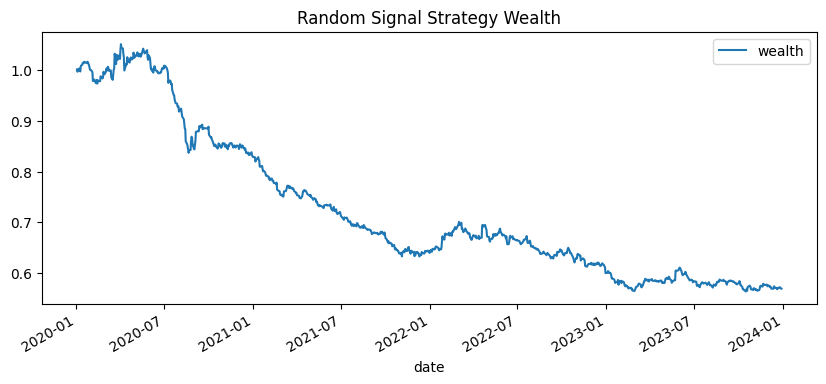

In [6]:
bt_random["wealth"] = (1.0 + bt_random["portfolio_return_net"]).cumprod()

bt_random.plot(
    x="date",
    y="wealth",
    figsize=(10, 4),
    title="Random Signal Strategy Wealth"
)

plt.show()

In [7]:
def run_signal_strategy(signal_col):
    weights = make_long_short_weights(
        signal_df=df,
        signal_col=signal_col,
        top_k=5,
        bottom_k=5,
        gross_exposure=1.0
    )

    returns = run_backtest(
        weights=weights,
        panel=df,
        forward_return_col="fwd_ret_1d"
    )

    turnover = compute_turnover(weights)

    bt = apply_transaction_costs(
        portfolio_returns=returns,
        turnover=turnover,
        cost_bps=5.0
    )

    metrics = summarize_returns(bt["portfolio_return_net"])
    metrics["avg_turnover"] = bt["turnover"].mean()

    return bt, weights, metrics


bt_random, weights_random, metrics_random = run_signal_strategy("signal_random")
bt_mom, weights_mom, metrics_mom = run_signal_strategy("signal_mom_5d")
bt_rev, weights_rev, metrics_rev = run_signal_strategy("signal_rev_5d")

In [8]:
metrics_table = pd.DataFrame([
    {"strategy": "random", **metrics_random},
    {"strategy": "momentum_5d", **metrics_mom},
    {"strategy": "reversal_5d", **metrics_rev},
])

metrics_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover
0,random,-0.131577,0.090772,-1.508454,-0.463396,1.661233
1,momentum_5d,-0.055471,0.161785,-0.271648,-0.402355,0.753247
2,reversal_5d,-0.147010,0.162005,-0.900404,-0.531862,0.753247


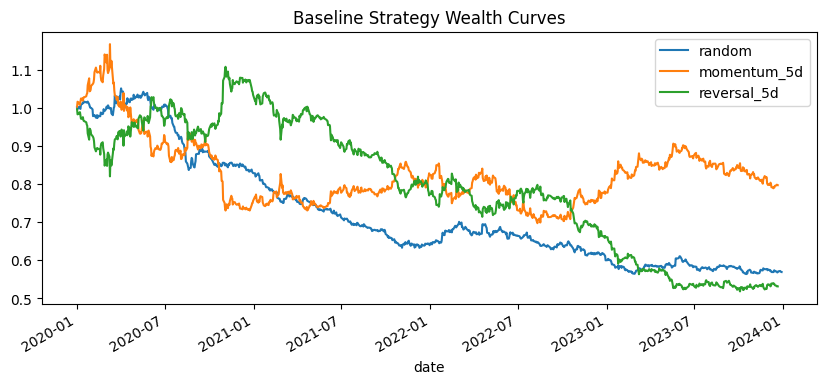

In [9]:
plot_df = pd.DataFrame({
    "date": bt_random["date"],
    "random": (1.0 + bt_random["portfolio_return_net"]).cumprod(),
    "momentum_5d": (1.0 + bt_mom["portfolio_return_net"]).cumprod(),
    "reversal_5d": (1.0 + bt_rev["portfolio_return_net"]).cumprod(),
})

plot_df.plot(
    x="date",
    y=["random", "momentum_5d", "reversal_5d"],
    figsize=(10, 4),
    title="Baseline Strategy Wealth Curves"
)

plt.show()

In [10]:
from src.risk import (
    check_weight_constraints,
    clip_and_renormalize_weights,
    apply_turnover_limit,
    summarize_constraint_violations,
)

In [11]:
def run_signal_strategy_with_risk_repair(
    signal_col,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=5.0
):
    # 1. Create naive weights
    weights_naive = make_long_short_weights(
        signal_df=df,
        signal_col=signal_col,
        top_k=5,
        bottom_k=5,
        gross_exposure=1.0
    )

    # 2. Check naive constraint violations
    naive_constraints = check_weight_constraints(
        weights_naive,
        max_abs_weight=max_abs_weight
    )

    naive_violation_summary = summarize_constraint_violations(
        naive_constraints
    )

    # 3. Repair position-size violations
    weights_repaired = clip_and_renormalize_weights(
        weights_naive,
        max_abs_weight=max_abs_weight,
        target_gross_exposure=1.0
    )

    # 4. Repair turnover violations
    weights_repaired = apply_turnover_limit(
        weights_repaired,
        max_turnover=max_turnover
    )

    # 5. Check repaired constraint violations
    repaired_constraints = check_weight_constraints(
        weights_repaired,
        max_abs_weight=max_abs_weight
    )

    repaired_violation_summary = summarize_constraint_violations(
        repaired_constraints
    )

    # 6. Backtest naive
    returns_naive = run_backtest(
        weights=weights_naive,
        panel=df,
        forward_return_col="fwd_ret_1d"
    )

    turnover_naive = compute_turnover(weights_naive)

    bt_naive = apply_transaction_costs(
        portfolio_returns=returns_naive,
        turnover=turnover_naive,
        cost_bps=cost_bps
    )

    metrics_naive = summarize_returns(bt_naive["portfolio_return_net"])
    metrics_naive["avg_turnover"] = bt_naive["turnover"].mean()
    metrics_naive["violation_rate"] = naive_violation_summary["violation_rate"]

    # 7. Backtest repaired
    returns_repaired = run_backtest(
        weights=weights_repaired,
        panel=df,
        forward_return_col="fwd_ret_1d"
    )

    turnover_repaired = compute_turnover(weights_repaired)

    bt_repaired = apply_transaction_costs(
        portfolio_returns=returns_repaired,
        turnover=turnover_repaired,
        cost_bps=cost_bps
    )

    metrics_repaired = summarize_returns(bt_repaired["portfolio_return_net"])
    metrics_repaired["avg_turnover"] = bt_repaired["turnover"].mean()
    metrics_repaired["violation_rate"] = repaired_violation_summary["violation_rate"]

    return {
        "bt_naive": bt_naive,
        "bt_repaired": bt_repaired,
        "weights_naive": weights_naive,
        "weights_repaired": weights_repaired,
        "metrics_naive": metrics_naive,
        "metrics_repaired": metrics_repaired,
    }

In [12]:
res_random = run_signal_strategy_with_risk_repair("signal_random")
res_mom = run_signal_strategy_with_risk_repair("signal_mom_5d")
res_rev = run_signal_strategy_with_risk_repair("signal_rev_5d")

In [13]:
risk_metrics_table = pd.DataFrame([
    {"strategy": "random_naive", **res_random["metrics_naive"]},
    {"strategy": "random_repaired", **res_random["metrics_repaired"]},

    {"strategy": "momentum_naive", **res_mom["metrics_naive"]},
    {"strategy": "momentum_repaired", **res_mom["metrics_repaired"]},

    {"strategy": "reversal_naive", **res_rev["metrics_naive"]},
    {"strategy": "reversal_repaired", **res_rev["metrics_repaired"]},
])

risk_metrics_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate
0,random_naive,-0.131577,0.090772,-1.508454,-0.463396,1.661233,0.0
1,random_repaired,-0.050307,0.042638,-1.189162,-0.211679,0.500497,0.0
2,momentum_naive,-0.055471,0.161785,-0.271648,-0.402355,0.753247,0.0
3,momentum_repaired,-0.040968,0.138661,-0.232186,-0.388771,0.493667,0.0
4,reversal_naive,-0.147010,0.162005,-0.900404,-0.531862,0.753247,0.0
5,reversal_repaired,-0.096812,0.138726,-0.664683,-0.420592,0.493667,0.0


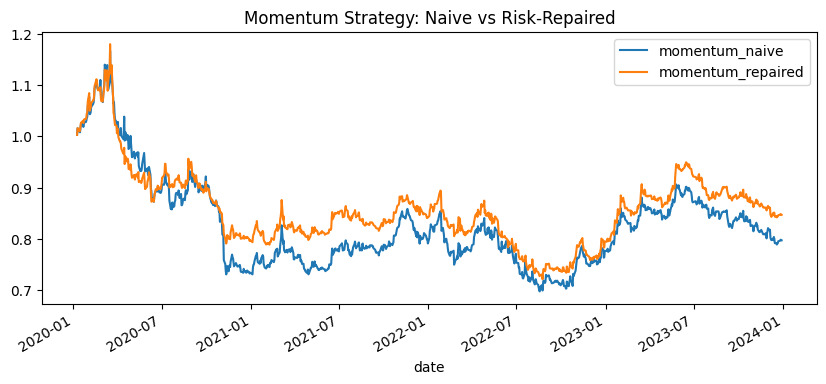

In [14]:
plot_df = pd.DataFrame({
    "date": res_mom["bt_naive"]["date"],
    "momentum_naive": (1.0 + res_mom["bt_naive"]["portfolio_return_net"]).cumprod(),
    "momentum_repaired": (1.0 + res_mom["bt_repaired"]["portfolio_return_net"]).cumprod(),
})

plot_df.plot(
    x="date",
    y=["momentum_naive", "momentum_repaired"],
    figsize=(10, 4),
    title="Momentum Strategy: Naive vs Risk-Repaired"
)

plt.show()

In [15]:
from src.portfolio import (
    make_long_short_weights,
    make_signal_weighted_long_short_weights,
)

In [16]:
def run_signal_weighted_strategy_with_risk_repair(
    signal_col,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=5.0
):
    # 1. Create aggressive confidence-weighted weights
    weights_naive = make_signal_weighted_long_short_weights(
        signal_df=df,
        signal_col=signal_col,
        top_k=5,
        bottom_k=5,
        gross_exposure=1.0
    )

    # 2. Check naive violations
    naive_constraints = check_weight_constraints(
        weights_naive,
        max_abs_weight=max_abs_weight
    )

    naive_violation_summary = summarize_constraint_violations(
        naive_constraints
    )

    # 3. Repair position-size violations
    weights_repaired = clip_and_renormalize_weights(
        weights_naive,
        max_abs_weight=max_abs_weight,
        target_gross_exposure=1.0
    )

    # 4. Repair turnover
    weights_repaired = apply_turnover_limit(
        weights_repaired,
        max_turnover=max_turnover
    )

    # 5. Check repaired violations
    repaired_constraints = check_weight_constraints(
        weights_repaired,
        max_abs_weight=max_abs_weight
    )

    repaired_violation_summary = summarize_constraint_violations(
        repaired_constraints
    )

    # 6. Backtest naive
    returns_naive = run_backtest(
        weights=weights_naive,
        panel=df,
        forward_return_col="fwd_ret_1d"
    )

    turnover_naive = compute_turnover(weights_naive)

    bt_naive = apply_transaction_costs(
        portfolio_returns=returns_naive,
        turnover=turnover_naive,
        cost_bps=cost_bps
    )

    metrics_naive = summarize_returns(bt_naive["portfolio_return_net"])
    metrics_naive["avg_turnover"] = bt_naive["turnover"].mean()
    metrics_naive["violation_rate"] = naive_violation_summary["violation_rate"]
    metrics_naive["avg_max_abs_weight"] = naive_violation_summary["avg_max_abs_weight"]

    # 7. Backtest repaired
    returns_repaired = run_backtest(
        weights=weights_repaired,
        panel=df,
        forward_return_col="fwd_ret_1d"
    )

    turnover_repaired = compute_turnover(weights_repaired)

    bt_repaired = apply_transaction_costs(
        portfolio_returns=returns_repaired,
        turnover=turnover_repaired,
        cost_bps=cost_bps
    )

    metrics_repaired = summarize_returns(bt_repaired["portfolio_return_net"])
    metrics_repaired["avg_turnover"] = bt_repaired["turnover"].mean()
    metrics_repaired["violation_rate"] = repaired_violation_summary["violation_rate"]
    metrics_repaired["avg_max_abs_weight"] = repaired_violation_summary["avg_max_abs_weight"]

    return {
        "bt_naive": bt_naive,
        "bt_repaired": bt_repaired,
        "weights_naive": weights_naive,
        "weights_repaired": weights_repaired,
        "metrics_naive": metrics_naive,
        "metrics_repaired": metrics_repaired,
    }

In [17]:
res_random_sw = run_signal_weighted_strategy_with_risk_repair("signal_random")
res_mom_sw = run_signal_weighted_strategy_with_risk_repair("signal_mom_5d")
res_rev_sw = run_signal_weighted_strategy_with_risk_repair("signal_rev_5d")

In [18]:
signal_weighted_metrics_table = pd.DataFrame([
    {"strategy": "random_signal_weighted_naive", **res_random_sw["metrics_naive"]},
    {"strategy": "random_signal_weighted_repaired", **res_random_sw["metrics_repaired"]},

    {"strategy": "momentum_signal_weighted_naive", **res_mom_sw["metrics_naive"]},
    {"strategy": "momentum_signal_weighted_repaired", **res_mom_sw["metrics_repaired"]},

    {"strategy": "reversal_signal_weighted_naive", **res_rev_sw["metrics_naive"]},
    {"strategy": "reversal_signal_weighted_repaired", **res_rev_sw["metrics_repaired"]},
])

signal_weighted_metrics_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,random_signal_weighted_naive,-0.156003,0.094400,-1.748907,-0.521727,1.718149,1.000000,0.154140
1,random_signal_weighted_repaired,-0.044220,0.043705,-1.012923,-0.199564,0.500497,0.004970,0.064282
2,momentum_signal_weighted_naive,-0.015208,0.184358,0.009267,-0.362974,0.836847,1.000000,0.199623
3,momentum_signal_weighted_repaired,-0.032902,0.150944,-0.145946,-0.384109,0.495944,0.893107,0.114987
4,reversal_signal_weighted_naive,-0.205178,0.184287,-1.153605,-0.608256,0.836847,1.000000,0.199623
5,reversal_signal_weighted_repaired,-0.108042,0.151014,-0.681714,-0.430272,0.495944,0.893107,0.114987


In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
res_random_sw = run_signal_weighted_strategy_with_risk_repair("signal_random")
res_mom_sw = run_signal_weighted_strategy_with_risk_repair("signal_mom_5d")
res_rev_sw = run_signal_weighted_strategy_with_risk_repair("signal_rev_5d")

signal_weighted_metrics_table = pd.DataFrame([
    {"strategy": "random_signal_weighted_naive", **res_random_sw["metrics_naive"]},
    {"strategy": "random_signal_weighted_repaired", **res_random_sw["metrics_repaired"]},

    {"strategy": "momentum_signal_weighted_naive", **res_mom_sw["metrics_naive"]},
    {"strategy": "momentum_signal_weighted_repaired", **res_mom_sw["metrics_repaired"]},

    {"strategy": "reversal_signal_weighted_naive", **res_rev_sw["metrics_naive"]},
    {"strategy": "reversal_signal_weighted_repaired", **res_rev_sw["metrics_repaired"]},
])

signal_weighted_metrics_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,random_signal_weighted_naive,-0.156003,0.094400,-1.748907,-0.521727,1.718149,1.0,0.154140
1,random_signal_weighted_repaired,-0.050307,0.042638,-1.189162,-0.211679,0.500497,0.0,0.062825
2,momentum_signal_weighted_naive,-0.015208,0.184358,0.009267,-0.362974,0.836847,1.0,0.199623
3,momentum_signal_weighted_repaired,-0.040968,0.138661,-0.232186,-0.388771,0.493667,0.0,0.096594
4,reversal_signal_weighted_naive,-0.205178,0.184287,-1.153605,-0.608256,0.836847,1.0,0.199623
5,reversal_signal_weighted_repaired,-0.096812,0.138726,-0.664683,-0.420592,0.493667,0.0,0.096594
